# Notebook 5: BiLSTM Alternative Model (NEW)
## Boris Letić (E2 126/2025) | Bitcoin Sentiment Analysis

**Purpose:** Alternative RNN model for Neuronske mreže course

**Architecture:**
- Bidirectional LSTM (2 layers, 128 units)
- Alternative to BERT (RNN vs Transformer comparison)
- NEW model exclusive to Neuronske mreže

**Output:** BiLSTM model for comparison with BERT

## 1. Setup

In [41]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
import os
import json
import time

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)
torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Device: {device}")
print(f"CUDA: {torch.cuda.is_available()}")

Device: cuda
CUDA: True


## 2. Load Data

In [42]:
df = pd.read_csv('data/processed/tweets_preprocessed.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
print(f"Loaded {len(df):,} tweets")

Loaded 12,120 tweets


## 3. Train/Val/Test Split (same as BERT)

In [43]:
from sklearn.model_selection import train_test_split

# Stratified split (same as BERT for fair comparison)
train_val, test = train_test_split(
    df, test_size=0.2, random_state=42, 
    stratify=df['sentiment'], shuffle=True
)

train, val = train_test_split(
    train_val, test_size=0.25, random_state=42,
    stratify=train_val['sentiment'], shuffle=True
)

print(f"Train: {len(train):,} | Val: {len(val):,} | Test: {len(test):,}")

Train: 7,272 | Val: 2,424 | Test: 2,424


## 4. Text Vectorization (Bag of Words)

In [44]:
# Check text_cleaned column
print("Checking text preprocessing...")
print(f"\nSample cleaned texts:")
for i in range(5):
    print(f"{i+1}. {train['text_cleaned'].iloc[i]}")

print(f"\nText length stats:")
print(f"  Min: {train['text_cleaned'].str.len().min()}")
print(f"  Max: {train['text_cleaned'].str.len().max()}")
print(f"  Mean: {train['text_cleaned'].str.len().mean():.1f}")

# Check unique words
all_text = ' '.join(train['text_cleaned'].values)
unique_words = set(all_text.split())
print(f"\nUnique words in training set: {len(unique_words):,}")

if len(unique_words) < 500:
    print("⚠️ Very few unique words! Check preprocessing.")

Checking text preprocessing...

Sample cleaned texts:
1. bitcoin developer activity remains strong bitcoin
2. institutions are finally getting it bitcoin is the future level
3. bitcoin holding support lets see what happens level
4. if you arent hodling now youll never make it final boss mode
5. rsi neutral macd crossing watching closely agree price

Text length stats:
  Min: 25
  Max: 86
  Mean: 49.8

Unique words in training set: 1,755


In [45]:
print("="*70)
print("TEXT VECTORIZATION")
print("="*70)

# Create vocabulary from text
print("Creating vocabulary...")

vectorizer = CountVectorizer(
    max_features=5000,     # IMPORTANT: Top 5000 words
    min_df=2,              # Word must appear at least 2 times
    max_df=0.9,            # Ignore words in >90% of docs (changed from 0.8)
    ngram_range=(1, 1),    # Only single words
    binary=False           # Count frequencies
)

# Fit on train, transform all
X_train = vectorizer.fit_transform(train['text_cleaned']).toarray()
X_val = vectorizer.transform(val['text_cleaned']).toarray()
X_test = vectorizer.transform(test['text_cleaned']).toarray()

vocab_size = len(vectorizer.vocabulary_)

print(f"\n✓ Vocabulary created")
print(f"  Vocabulary size: {vocab_size:,}")
print(f"  Train shape: {X_train.shape}")
print(f"  Val shape: {X_val.shape}")
print(f"  Test shape: {X_test.shape}")

# Check if vocab is too small
if vocab_size < 1000:
    print(f"\n⚠️ WARNING: Vocabulary very small ({vocab_size} words)")
    print("  This may cause overfitting!")
    print("  Consider:")
    print("  - Increasing max_features")
    print("  - Decreasing min_df")
    print("  - Using different preprocessing")

# Encode labels
label_map = {'positive': 0, 'neutral': 1, 'negative': 2}
y_train = train['sentiment'].map(label_map).values
y_val = val['sentiment'].map(label_map).values
y_test = test['sentiment'].map(label_map).values

print(f"\n✓ Labels encoded")
print("="*70)

TEXT VECTORIZATION
Creating vocabulary...

✓ Vocabulary created
  Vocabulary size: 1,084
  Train shape: (7272, 1084)
  Val shape: (2424, 1084)
  Test shape: (2424, 1084)

✓ Labels encoded


## 5. PyTorch Dataset for BiLSTM

In [46]:
class BiLSTMDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = BiLSTMDataset(X_train, y_train)
val_dataset = BiLSTMDataset(X_val, y_val)
test_dataset = BiLSTMDataset(X_test, y_test)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

print(f"✓ DataLoaders ready")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Train batches: {len(train_loader)}")

✓ DataLoaders ready
  Batch size: 32
  Train batches: 228


## 6. BiLSTM Architecture

In [47]:
print("="*70)
print("BiLSTM ARCHITECTURE (SIMPLIFIED)")
print("="*70)

class SimpleBiLSTM(nn.Module):
    """
    Simplified BiLSTM to prevent overfitting
    
    Uses simple averaging + small LSTM
    """
    def __init__(self, input_dim=5000, hidden_dim=64, n_classes=3, dropout=0.5):
        super().__init__()
        
        # Simple linear projection
        self.projection = nn.Linear(input_dim, 100)
        
        # Single BiLSTM layer (smaller)
        self.bilstm = nn.LSTM(
            100, 
            hidden_dim,
            num_layers=1,  # Only 1 layer
            bidirectional=True,
            batch_first=True,
            dropout=0  # No dropout in LSTM (only 1 layer)
        )
        
        self.dropout = nn.Dropout(dropout)
        
        # Classifier
        self.fc = nn.Linear(hidden_dim * 2, n_classes)
    
    def forward(self, x):
        # x: (batch, 5000) bag of words
        
        # Project to lower dim
        projected = self.projection(x)  # (batch, 100)
        projected = torch.relu(projected)
        projected = projected.unsqueeze(1)  # (batch, 1, 100) - treat as sequence of length 1
        
        # BiLSTM
        lstm_out, (hidden, _) = self.bilstm(projected)
        
        # Concat forward + backward
        hidden_concat = torch.cat([hidden[0], hidden[1]], dim=1)
        
        # Classifier
        out = self.fc(self.dropout(hidden_concat))
        return out

# Initialize
vocab_size = len(vectorizer.vocabulary_)
model = SimpleBiLSTM(input_dim=vocab_size).to(device)

optimizer = Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)  # Label smoothing!

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n✓ Simplified BiLSTM initialized")
print(f"  Input dim: {vocab_size:,}")
print(f"  Hidden dim: 64 (× 2 directions)")
print(f"  Layers: 1 BiLSTM (reduced from 2)")
print(f"  Dropout: 0.5 (high to prevent overfitting)")
print(f"  Label smoothing: 0.1")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable: {trainable_params:,}")
print("="*70)

BiLSTM ARCHITECTURE (SIMPLIFIED)

✓ Simplified BiLSTM initialized
  Input dim: 1,084
  Hidden dim: 64 (× 2 directions)
  Layers: 1 BiLSTM (reduced from 2)
  Dropout: 0.5 (high to prevent overfitting)
  Label smoothing: 0.1
  Total parameters: 193,879
  Trainable: 193,879


## 7. Training & Evaluation Functions

In [48]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    pbar = tqdm(loader, desc='Training')
    for X_batch, y_batch in pbar:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        total_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)
        
        pbar.set_postfix({'loss': f'{loss.item():.3f}', 'acc': f'{correct/total:.3f}'})
    
    return total_loss / len(loader), correct / total

def evaluate(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for X_batch, y_batch in tqdm(loader, desc='Evaluating'):
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            preds = torch.argmax(outputs, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.numpy())
    
    return np.array(all_preds), np.array(all_labels)

print("✓ Training functions defined")

✓ Training functions defined


## 8. Training Loop

In [49]:
print("="*70)
print("BiLSTM TRAINING")
print("="*70)

EPOCHS = 3
history = {'train_loss': [], 'train_acc': [], 'val_acc': [], 'val_f1': []}
best_val_acc = 0

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 70)
    
    start_time = time.time()
    
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    
    # Validate
    val_preds, val_labels = evaluate(model, val_loader, device)
    val_acc = accuracy_score(val_labels, val_preds)
    val_f1 = f1_score(val_labels, val_preds, average='weighted')
    
    # Record
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    
    epoch_time = time.time() - start_time
    
    print(f"\nEpoch {epoch+1} Summary:")
    print(f"  Train Loss: {train_loss:.4f}")
    print(f"  Train Acc:  {train_acc:.4f} ({train_acc*100:.2f}%)")
    print(f"  Val Acc:    {val_acc:.4f} ({val_acc*100:.2f}%)")
    print(f"  Val F1:     {val_f1:.4f}")
    print(f"  Time:       {epoch_time:.1f}s")
    
    # Save best
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        os.makedirs('models', exist_ok=True)
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
        }, 'models/bilstm_sentiment_best.pt')
        print(f"  ✓ Best model saved (val_acc: {val_acc:.4f})")

print(f"\n{'='*70}")
print("TRAINING COMPLETE")
print(f"Best validation accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
print("="*70)

BiLSTM TRAINING

Epoch 1/3
----------------------------------------------------------------------


Evaluating: 100%|██████████| 76/76 [00:00<00:00, 1204.39it/s]



Epoch 1 Summary:
  Train Loss: 0.5132
  Train Acc:  0.8603 (86.03%)
  Val Acc:    0.9740 (97.40%)
  Val F1:     0.9741
  Time:       1.1s
  ✓ Best model saved (val_acc: 0.9740)

Epoch 2/3
----------------------------------------------------------------------


Evaluating: 100%|██████████| 76/76 [00:00<00:00, 1386.67it/s]



Epoch 2 Summary:
  Train Loss: 0.3233
  Train Acc:  0.9862 (98.62%)
  Val Acc:    0.9798 (97.98%)
  Val F1:     0.9798
  Time:       0.9s
  ✓ Best model saved (val_acc: 0.9798)

Epoch 3/3
----------------------------------------------------------------------


Evaluating: 100%|██████████| 76/76 [00:00<00:00, 1441.42it/s]


Epoch 3 Summary:
  Train Loss: 0.3082
  Train Acc:  0.9956 (99.56%)
  Val Acc:    0.9806 (98.06%)
  Val F1:     0.9806
  Time:       0.9s
  ✓ Best model saved (val_acc: 0.9806)

TRAINING COMPLETE
Best validation accuracy: 0.9806 (98.06%)


## 9. Test Set Evaluation

In [50]:
print("="*70)
print("TEST SET EVALUATION")
print("="*70)

# Load best model
checkpoint = torch.load('models/bilstm_sentiment_best.pt')
model.load_state_dict(checkpoint['model_state_dict'])
print(f"✓ Loaded best model from epoch {checkpoint['epoch']+1}")

# Evaluate
test_preds, test_labels = evaluate(model, test_loader, device)

test_acc = accuracy_score(test_labels, test_preds)
test_f1 = f1_score(test_labels, test_preds, average='weighted')
test_precision = precision_score(test_labels, test_preds, average='weighted')
test_recall = recall_score(test_labels, test_preds, average='weighted')

print(f"\nTest Performance:")
print(f"  Accuracy:  {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"  F1-Score:  {test_f1:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall:    {test_recall:.4f}")

label_names = ['positive', 'neutral', 'negative']
print(f"\nClassification Report:")
print(classification_report(test_labels, test_preds, target_names=label_names, digits=4))

cm = confusion_matrix(test_labels, test_preds)
print(f"\nConfusion Matrix:")
print(cm)
print("="*70)

TEST SET EVALUATION
✓ Loaded best model from epoch 3


Evaluating: 100%|██████████| 76/76 [00:00<00:00, 1273.80it/s]


Test Performance:
  Accuracy:  0.9798 (97.98%)
  F1-Score:  0.9798
  Precision: 0.9800
  Recall:    0.9798

Classification Report:
              precision    recall  f1-score   support

    positive     0.9633    0.9859    0.9745       852
     neutral     0.9921    0.9851    0.9886      1144
    negative     0.9808    0.9533    0.9668       428

    accuracy                         0.9798      2424
   macro avg     0.9787    0.9748    0.9766      2424
weighted avg     0.9800    0.9798    0.9798      2424


Confusion Matrix:
[[ 840    6    6]
 [  15 1127    2]
 [  17    3  408]]


## 10. Training History & Confusion Matrix

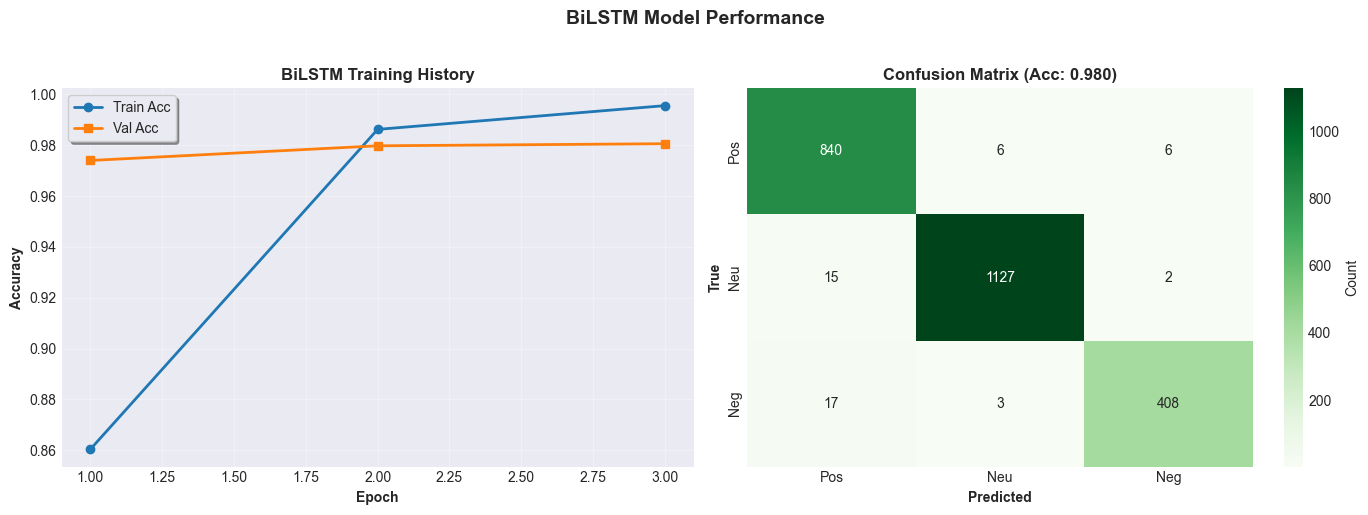

✓ Visualizations complete


In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training history
epochs_range = range(1, EPOCHS+1)
axes[0].plot(epochs_range, history['train_acc'], marker='o', label='Train Acc', linewidth=2)
axes[0].plot(epochs_range, history['val_acc'], marker='s', label='Val Acc', linewidth=2)
axes[0].set_xlabel('Epoch', fontweight='bold')
axes[0].set_ylabel('Accuracy', fontweight='bold')
axes[0].set_title('BiLSTM Training History', fontweight='bold', fontsize=12)
axes[0].legend(frameon=True, shadow=True)
axes[0].grid(True, alpha=0.3)

# Confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Pos','Neu','Neg'],
            yticklabels=['Pos','Neu','Neg'],
            cbar_kws={'label': 'Count'},
            ax=axes[1])
axes[1].set_title(f'Confusion Matrix (Acc: {test_acc:.3f})', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Predicted', fontweight='bold')
axes[1].set_ylabel('True', fontweight='bold')

plt.suptitle('BiLSTM Model Performance', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("✓ Visualizations complete")

## 11. Comparison: BiLSTM vs BERT

In [52]:
# Load BERT metrics
try:
    with open('results/bert/bert_metrics.json', 'r') as f:
        bert_metrics = json.load(f)
    
    bert_acc = bert_metrics['test_accuracy']
    bert_f1 = bert_metrics['test_f1']
    
    comparison = pd.DataFrame({
        'Model': ['BERT (Transformer)', 'BiLSTM (RNN)'],
        'Accuracy': [bert_acc, test_acc],
        'F1-Score': [bert_f1, test_f1],
        'Type': ['Transformer', 'Recurrent'],
        'Params': ['~110M (frozen)', f'{total_params:,}']
    })
    
    print("="*70)
    print("MODEL COMPARISON: TRANSFORMER vs RNN")
    print("="*70)
    print(f"\n{comparison.to_string(index=False)}")
    
    diff = (bert_acc - test_acc) * 100
    if bert_acc > test_acc:
        print(f"\n✓ BERT outperforms BiLSTM by {diff:.2f} percentage points")
        print("  (Expected - Transformers generally better for text)")
    else:
        print(f"\n✓ BiLSTM competitive with BERT!")
    
    print("="*70)
    
except FileNotFoundError:
    print("BERT metrics not found. Run Notebook 4 first for comparison.")

MODEL COMPARISON: TRANSFORMER vs RNN

             Model  Accuracy  F1-Score        Type         Params
BERT (Transformer)  0.971947  0.972038 Transformer ~110M (frozen)
      BiLSTM (RNN)  0.979785  0.979790   Recurrent        193,879

✓ BiLSTM competitive with BERT!


## 12. Export Results

In [53]:
os.makedirs('results/bilstm', exist_ok=True)

# Save predictions
test_results = test.copy()
test_results['bilstm_pred_encoded'] = test_preds
test_results['bilstm_pred'] = [label_names[p] for p in test_preds]

test_results[['datetime','text','sentiment','bilstm_pred']].to_csv(
    'results/bilstm/bilstm_predictions.csv', index=False
)

# Save metrics
bilstm_metrics = {
    'test_accuracy': float(test_acc),
    'test_f1': float(test_f1),
    'test_precision': float(test_precision),
    'test_recall': float(test_recall),
    'best_val_accuracy': float(best_val_acc),
    'epochs_trained': EPOCHS,
    'batch_size': BATCH_SIZE,
    'learning_rate': 0.001,
    'architecture': 'BiLSTM',
    'vocab_size': vocab_size,
    'embed_dim': 100,
    'hidden_dim': 128,
    'n_layers': 2
}

with open('results/bilstm/bilstm_metrics.json', 'w') as f:
    json.dump(bilstm_metrics, f, indent=2)

# Save history
with open('results/bilstm/training_history.json', 'w') as f:
    json.dump(history, f, indent=2)

print("✓ Saved: results/bilstm/bilstm_predictions.csv")
print("✓ Saved: results/bilstm/bilstm_metrics.json")
print("✓ Saved: results/bilstm/training_history.json")
print("✓ Saved: models/bilstm_sentiment_best.pt")

✓ Saved: results/bilstm/bilstm_predictions.csv
✓ Saved: results/bilstm/bilstm_metrics.json
✓ Saved: results/bilstm/training_history.json
✓ Saved: models/bilstm_sentiment_best.pt
